# 04 — Spatial Analysis
**Project:** Spatial–Temporal Analysis and Demand Forecasting of Ride-Hailing Mobility

**Purpose:** Spatial analysis of NYC TLC FHVHV trip demand using KDE, Getis-Ord Gi* hotspot detection, and LISA (Local Moran's I) spatial autocorrelation.

**Output:** Choropleth maps + spatial statistics saved to `outputs/spatial/` and written back to PostgreSQL (`spatial_statistics` table).

**Tables used:** `hourly_demand`, `taxi_zones`

## 0 · Setup

In [1]:
!pip install geopandas pysal libpysal esda splot folium mapclassify psycopg2-binary sqlalchemy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 12.4 MB/s eta 0:00:00


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import folium
from folium.plugins import HeatMap
from sqlalchemy import create_engine, text
from scipy.stats import gaussian_kde

# PySAL spatial stats
import libpysal
from libpysal.weights import Queen
from esda.getisord import G_Local
from esda.moran import Moran, Moran_Local
from splot.esda import plot_local_autocorrelation, lisa_cluster

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

os.makedirs('outputs/spatial', exist_ok=True)
print('Setup complete.')

Setup complete.


In [3]:
# ── Database connection ─────────────────────────────────────
PG_HOST = '0.tcp.ngrok.io'
PG_PORT = 18545
PG_DB   = 'rides'
PG_USER = 'rides'
PG_PASS = 'rides'

engine = create_engine(
    f'postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}',
    pool_pre_ping=True,
)

with engine.connect() as conn:
    n = conn.execute(text('SELECT COUNT(*) FROM hourly_demand')).scalar()
    print(f'hourly_demand rows: {n:,}')

hourly_demand rows: 181,571


## 1 · Load Data & NYC Shapefile

In [4]:
import zipfile, pathlib
import geopandas as gpd
from google.colab import drive

# ── Mount Google Drive ──────────────────────────────────────
drive.mount('/content/drive', force_remount=False)

# ── Path of Drive ───────────────────────────────
DRIVE_ZIP = pathlib.Path('/content/drive/MyDrive/Colab Notebooks/shapefile_upload.zip')

SHP_DIR  = pathlib.Path('data/taxi_zones')
SHP_FILE = SHP_DIR / 'taxi_zones.shp'
SHP_DIR.mkdir(parents=True, exist_ok=True)

if not SHP_FILE.exists():
    if DRIVE_ZIP.exists():
        print(f'Loading shapefile from Drive: {DRIVE_ZIP}')
        with zipfile.ZipFile(DRIVE_ZIP, 'r') as z:
            z.extractall(SHP_DIR)
        print('Extracted successfully.')
    else:
        print(f'ERROR: File not found on Drive: {DRIVE_ZIP}')
        print('Please upload shapefile_upload.zip to Google Drive at:')
        print(f'  {DRIVE_ZIP}')
        raise FileNotFoundError(str(DRIVE_ZIP))
else:
    print('Shapefile already exists in session — skipping extraction.')

# ── Load shapefile ───────────────────────────────────────────
gdf = gpd.read_file(SHP_FILE)
gdf = gdf.to_crs(epsg=4326)
gdf = gdf.rename(columns={'LocationID': 'zone_id'})
print(f'Shapefile zones: {len(gdf)}')
gdf.head(3)

Mounted at /content/drive
Loading shapefile from Drive: /content/drive/MyDrive/Colab Notebooks/shapefile_upload.zip
Extracted successfully.
Shapefile zones: 263


,OBJECTID,Shape_Leng,Shape_Area,zone,zone_id,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((-74.18445 40.695, -74.18449 40.6951,..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((-73.84793 40.87134, -73.84725 40.870..."


In [5]:
# Aggregate total demand per zone from DB
demand_sql = """
SELECT
    hd.zone_id,
    z.zone_name,
    z.borough,
    z.centroid_lat,
    z.centroid_lon,
    SUM(hd.pickup_count)    AS total_pickups,
    AVG(hd.pickup_count)    AS avg_pickups,
    SUM(hd.dropoff_count)   AS total_dropoffs
FROM hourly_demand hd
JOIN taxi_zones z ON z.zone_id = hd.zone_id
GROUP BY hd.zone_id, z.zone_name, z.borough, z.centroid_lat, z.centroid_lon
"""
demand_df = pd.read_sql(demand_sql, engine)
print(f'Zones with demand data: {len(demand_df)}')

gdf_demand = (
    gdf.drop(columns=['borough'], errors='ignore')
       .merge(demand_df, on='zone_id', how='left')
)
gdf_demand['total_pickups'] = gdf_demand['total_pickups'].fillna(0)
gdf_demand['avg_pickups']   = gdf_demand['avg_pickups'].fillna(0)
print(f'Merged GeoDataFrame: {len(gdf_demand)} zones')
print(f'Columns: {list(gdf_demand.columns)}')

Zones with demand data: 262
Merged GeoDataFrame: 263 zones
Columns: ['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'zone_id', 'geometry', 'zone_name', 'borough', 'centroid_lat', 'centroid_lon', 'total_pickups', 'avg_pickups', 'total_dropoffs']


## 2 · Choropleth Map — Total Pickup Demand

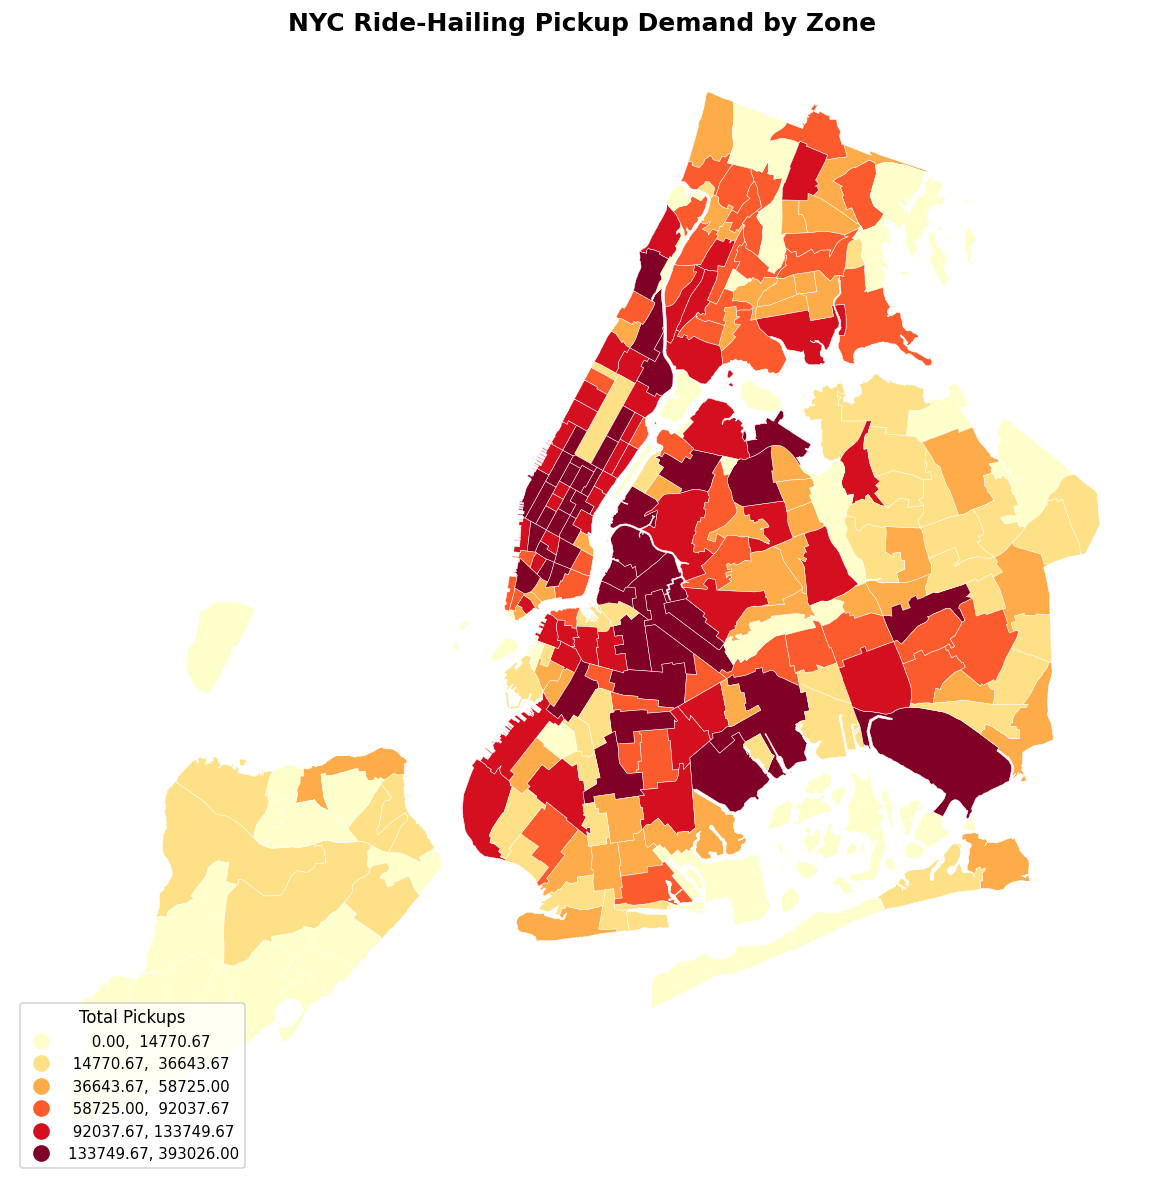

Saved: outputs/spatial/01_choropleth_demand.png


In [6]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf_demand.plot(
    column='total_pickups',
    ax=ax,
    cmap='YlOrRd',
    scheme='quantiles',
    k=6,
    legend=True,
    legend_kwds={'title': 'Total Pickups', 'loc': 'lower left', 'fontsize': 9, 'title_fontsize': 10},
    edgecolor='white',
    linewidth=0.3,
    missing_kwds={'color': '#EEEEEE', 'label': 'No data'},
)

ax.set_title('NYC Ride-Hailing Pickup Demand by Zone', fontsize=15, fontweight='bold')
ax.set_axis_off()

plt.tight_layout()
plt.savefig('outputs/spatial/01_choropleth_demand.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/spatial/01_choropleth_demand.png')

In [7]:
# Interactive Folium choropleth
m = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='CartoDB positron')

folium.Choropleth(
    geo_data=gdf_demand.__geo_interface__,
    name='Total Pickups',
    data=gdf_demand[['zone_id', 'total_pickups']],
    columns=['zone_id', 'total_pickups'],
    key_on='feature.properties.zone_id',
    fill_color='YlOrRd',
    fill_opacity=0.75,
    line_opacity=0.2,
    legend_name='Total Pickups',
    nan_fill_color='#EEEEEE',
).add_to(m)

# Tooltip
folium.GeoJson(
    gdf_demand,
    style_function=lambda x: {'fillOpacity': 0, 'weight': 0},
    tooltip=folium.GeoJsonTooltip(
        fields=['zone_name', 'borough', 'total_pickups'],
        aliases=['Zone', 'Borough', 'Total Pickups'],
        localize=True,
    )
).add_to(m)

m.save('outputs/spatial/02_choropleth_interactive.html')
print('Saved: outputs/spatial/02_choropleth_interactive.html')
m

Output hidden; open in https://colab.research.google.com to view.

## 3 · KDE — Kernel Density Estimation

In [8]:
# Build KDE from zone centroids weighted by pickup count (log-scaled)
kde_df = gdf_demand[
    (gdf_demand['centroid_lat'].notna()) &
    (gdf_demand['centroid_lon'].notna()) &
    (gdf_demand['total_pickups'] > 0)
].copy()

# Log-transform compresses Manhattan's 100x dominance over the outer boroughs
weights = np.log1p(kde_df['total_pickups'].values)
lats = kde_df['centroid_lat'].values
lons = kde_df['centroid_lon'].values

# scipy's gaussian_kde takes native weights — no np.repeat needed
xy = np.vstack([lons, lats])
kde = gaussian_kde(xy, weights=weights, bw_method=0.25)

# Grid for evaluation — clamp to NYC bounding box (don't follow the centroids)
lon_min, lon_max = -74.26, -73.70
lat_min, lat_max = 40.48, 40.92
xx, yy = np.mgrid[lon_min:lon_max:300j, lat_min:lat_max:300j]
positions = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(positions).reshape(xx.shape)

print(f'KDE computed on {len(lats)} zones, weight range {weights.min():.1f}–{weights.max():.1f}')

KDE computed on 261 zones, weight range 0.7–12.9


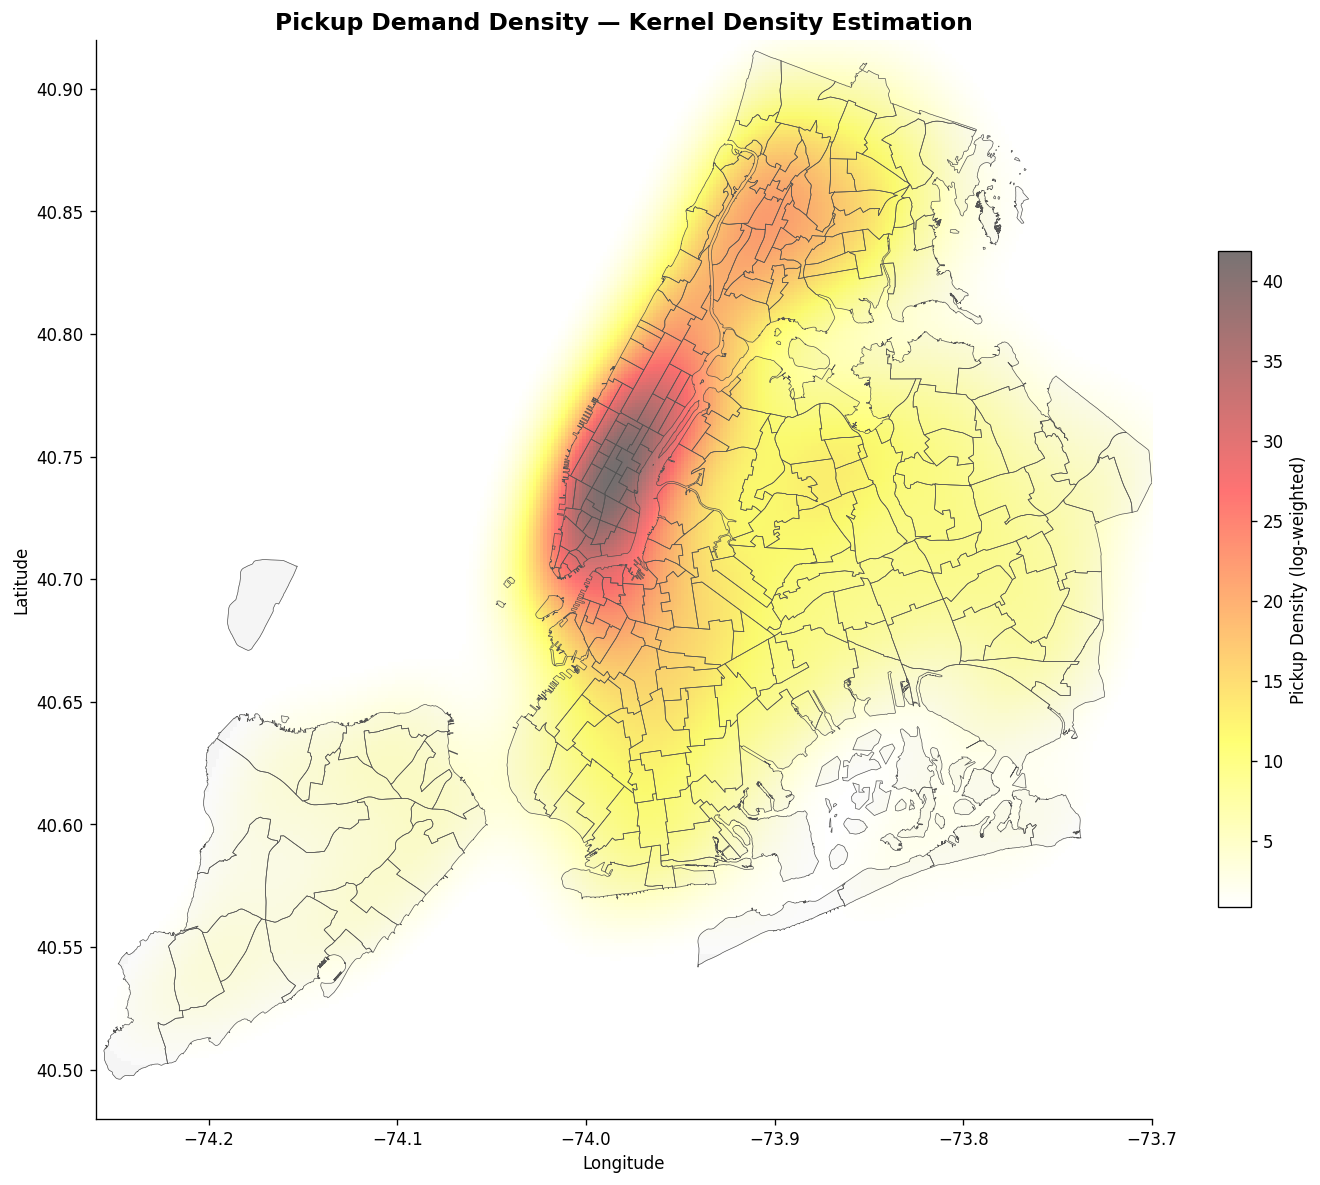

In [9]:
fig, ax = plt.subplots(figsize=(12, 10))

# Base — fill zones in light grey
gdf_demand.plot(ax=ax, color='#F5F5F5', edgecolor='#CCCCCC', linewidth=0.3, zorder=0)

# KDE surface — more translucent so borders below show through
zz_masked = np.ma.masked_where(zz < zz.max() * 0.02, zz)
img = ax.imshow(
    zz_masked.T,
    origin='lower',
    extent=[lon_min, lon_max, lat_min, lat_max],
    cmap='hot_r',
    alpha=0.55,           # was 0.75
    aspect='auto',
    zorder=1,
)
plt.colorbar(img, ax=ax, label='Pickup Density (log-weighted)', shrink=0.6)

# Borders ON TOP of the KDE — this is the key change
gdf_demand.boundary.plot(ax=ax, edgecolor='#555555', linewidth=0.4, zorder=2)

ax.set_aspect(1.3)
ax.set_title('Pickup Demand Density — Kernel Density Estimation', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_xlim(lon_min, lon_max); ax.set_ylim(lat_min, lat_max)

plt.tight_layout()
plt.savefig('outputs/spatial/03_kde_density.png', bbox_inches='tight', dpi=150)
plt.show()

In [10]:
# Interactive Folium heatmap
heat_data = [
    [row['centroid_lat'], row['centroid_lon'], row['total_pickups']]
    for _, row in kde_df.iterrows()
]

m2 = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='CartoDB dark_matter')
HeatMap(heat_data, radius=20, blur=15, max_zoom=13).add_to(m2)
m2.save('outputs/spatial/04_kde_heatmap_interactive.html')
print('Saved: outputs/spatial/04_kde_heatmap_interactive.html')
m2

Saved: outputs/spatial/04_kde_heatmap_interactive.html


## 4 · Getis-Ord Gi* — Hotspot Detection

In [11]:
from libpysal.weights import Queen, KNN, w_union

gdf_gi = gdf_demand[gdf_demand['total_pickups'] > 0].copy().reset_index(drop=True)

w_queen = Queen.from_dataframe(gdf_gi, use_index=False, silence_warnings=True)
w_knn   = KNN.from_dataframe(gdf_gi, k=8)
w = w_union(w_queen, w_knn, silence_warnings=True)  # repairs disconnected islands
w.transform = 'r'

print(f'Zones: {w.n}  |  islands fixed: {len(w_queen.islands)} → {len(w.islands)}')

Zones: 261  |  islands fixed: 4 → 0


In [12]:
# Compute Gi* statistic
gi = G_Local(gdf_gi['total_pickups'], w, star=True, permutations=999)

gdf_gi['gi_z']   = gi.Zs          # z-score
gdf_gi['gi_p']   = gi.p_sim       # p-value (permutation)

# Classify significance — use permutation p-value alone (PySAL convention).
# Sign of z determines hot vs cold; magnitude of p determines confidence band.
def classify_hotspot(z, p):
    if z > 0:                              # hot
        if p < 0.01:   return 'Hot spot 99%'
        if p < 0.05:   return 'Hot spot 95%'
        if p < 0.10:   return 'Hot spot 90%'
    else:                                  # cold
        if p < 0.01:   return 'Cold spot 99%'
        if p < 0.05:   return 'Cold spot 95%'
        if p < 0.10:   return 'Cold spot 90%'
    return 'Not significant'

gdf_gi['hotspot_class'] = [
    classify_hotspot(z, p)
    for z, p in zip(gdf_gi['gi_z'], gdf_gi['gi_p'])
]

print('=== Hotspot Classification ===')
print(gdf_gi['hotspot_class'].value_counts().to_string())
print(f"\nZ-score range: {gdf_gi['gi_z'].min():.2f} to {gdf_gi['gi_z'].max():.2f}")
print(f"P-value range:  {gdf_gi['gi_p'].min():.3f} to {gdf_gi['gi_p'].max():.3f}")


=== Hotspot Classification ===
hotspot_class
Not significant    137
Hot spot 99%        34
Cold spot 99%       30
Cold spot 95%       16
Hot spot 95%        16
Cold spot 90%       15
Hot spot 90%        13

Z-score range: -1.04 to 1.75
P-value range:  0.001 to 0.496


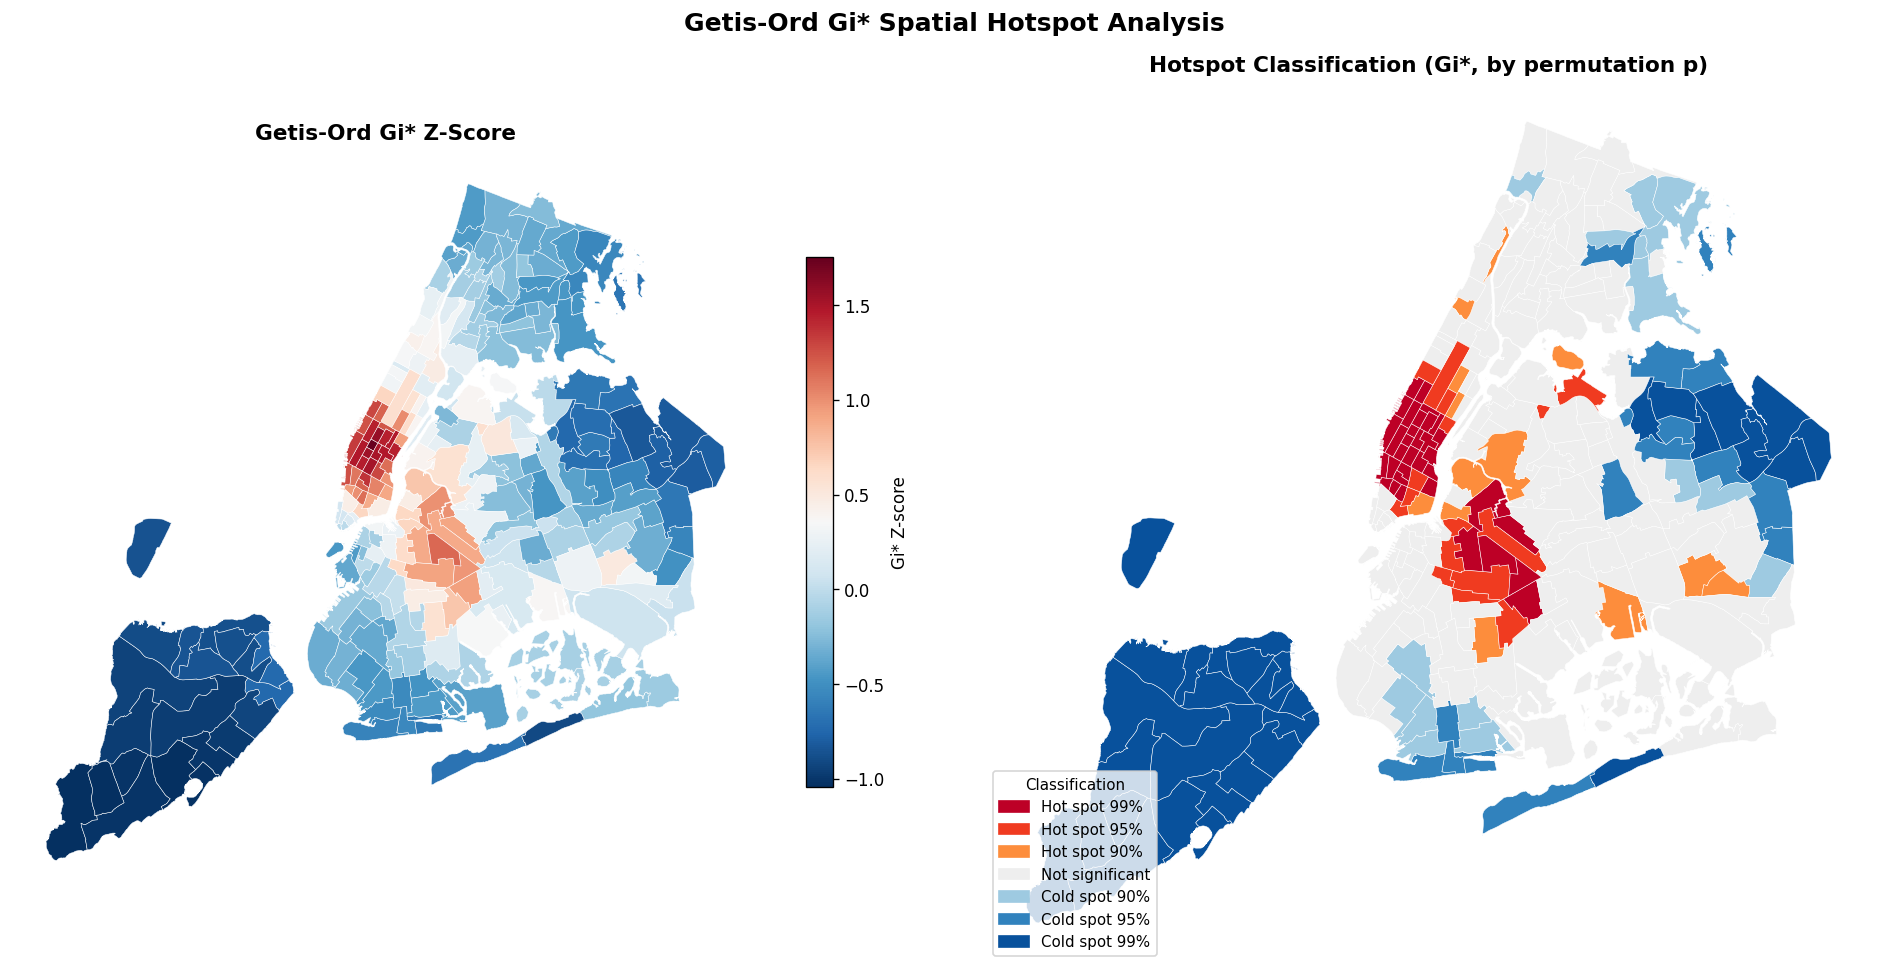


Top 10 Hotspot Zones:
                   zone_name   borough     gi_z  gi_p hotspot_class
            Garment District Manhattan 1.751313 0.001  Hot spot 99%
   Times Sq/Theatre District Manhattan 1.567351 0.002  Hot spot 99%
Penn Station/Madison Sq West Manhattan 1.533539 0.001  Hot spot 99%
                    Union Sq Manhattan 1.520288 0.001  Hot spot 99%
               Midtown South Manhattan 1.509828 0.002  Hot spot 99%
                 Murray Hill Manhattan 1.475150 0.001  Hot spot 99%
                Midtown East Manhattan 1.471910 0.001  Hot spot 99%
                East Chelsea Manhattan 1.467819 0.004  Hot spot 99%
                    Flatiron Manhattan 1.456271 0.002  Hot spot 99%
              Midtown Center Manhattan 1.442000 0.002  Hot spot 99%


In [13]:
HOTSPOT_COLORS = {
    'Hot spot 99%':    '#BD0026',
    'Hot spot 95%':    '#F03B20',
    'Hot spot 90%':    '#FD8D3C',
    'Not significant': '#EEEEEE',
    'Cold spot 90%':   '#9ECAE1',
    'Cold spot 95%':   '#3182BD',
    'Cold spot 99%':   '#08519C',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Left: Gi* Z-score continuous ────────────────────────────
ax = axes[0]
gdf_gi.plot(column='gi_z', ax=ax, cmap='RdBu_r',
            legend=True,
            legend_kwds={'label': 'Gi* Z-score', 'shrink': 0.6},
            edgecolor='white', linewidth=0.3)
ax.set_title('Getis-Ord Gi* Z-Score', fontsize=13, fontweight='bold')
ax.set_axis_off()

# ── Right: Classified hotspots ───────────────────────────────
ax = axes[1]
gdf_gi['color'] = gdf_gi['hotspot_class'].map(HOTSPOT_COLORS)
gdf_gi.plot(ax=ax, color=gdf_gi['color'], edgecolor='white', linewidth=0.3)
ax.set_title('Hotspot Classification (Gi*, by permutation p)', fontsize=13, fontweight='bold')
ax.set_axis_off()

# Legend — order from highest hot → coldest cold for natural reading
LEGEND_ORDER = [
    'Hot spot 99%', 'Hot spot 95%', 'Hot spot 90%',
    'Not significant',
    'Cold spot 90%', 'Cold spot 95%', 'Cold spot 99%',
]
present = set(gdf_gi['hotspot_class'].unique())
legend_patches = [
    mpatches.Patch(color=HOTSPOT_COLORS[l], label=l)
    for l in LEGEND_ORDER if l in present
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9,
          title='Classification', title_fontsize=9)

plt.suptitle('Getis-Ord Gi* Spatial Hotspot Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/spatial/05_getis_ord_hotspot.png', bbox_inches='tight', dpi=150)
plt.show()

# Top hotspot zones
top_hot = gdf_gi[gdf_gi['hotspot_class'].str.startswith('Hot')]\
    .sort_values('gi_z', ascending=False)[['zone_name','borough','gi_z','gi_p','hotspot_class']].head(10)
print('\nTop 10 Hotspot Zones:')
print(top_hot.to_string(index=False))


## 5 · LISA — Local Moran's I (Spatial Autocorrelation)

In [14]:
# Global Moran's I first
moran_global = Moran(gdf_gi['total_pickups'], w, permutations=999)
print(f"Global Moran's I: {moran_global.I:.4f}")
print(f"Expected I:       {moran_global.EI:.4f}")
print(f"p-value:          {moran_global.p_sim:.4f}")
print(f"z-score:          {moran_global.z_norm:.4f}")

if moran_global.p_sim < 0.05:
    direction = 'positive' if moran_global.I > 0 else 'negative'
    print(f"\n→ Statistically significant {direction} spatial autocorrelation (p<0.05)")
    print(  "  Similar demand values tend to cluster together spatially.")
else:
    print("\n→ No significant spatial autocorrelation detected.")

Global Moran's I: 0.3546
Expected I:       -0.0038
p-value:          0.0010
z-score:          12.6804

→ Statistically significant positive spatial autocorrelation (p<0.05)
  Similar demand values tend to cluster together spatially.


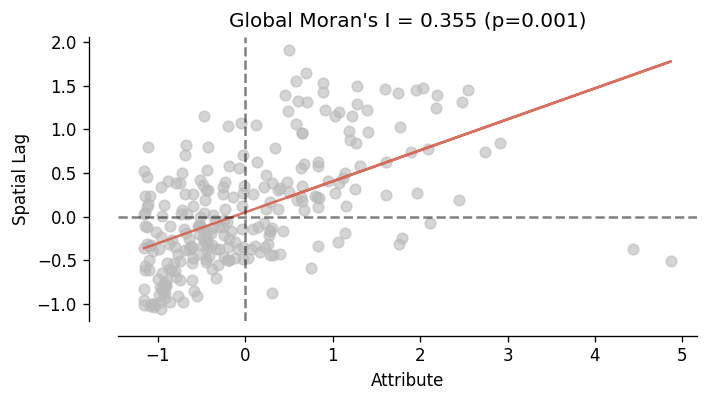

In [15]:
# Moran scatter plot
from splot.esda import moran_scatterplot
fig, ax = plt.subplots(figsize=(6, 6))
moran_scatterplot(moran_global, ax=ax)
ax.set_title(f"Global Moran's I = {moran_global.I:.3f} (p={moran_global.p_sim:.3f})",
             fontsize=12)
plt.tight_layout()
plt.savefig('outputs/spatial/06_moran_global.png', bbox_inches='tight', dpi=150)
plt.show()

In [16]:
# Local Moran's I (LISA)
lisa = Moran_Local(gdf_gi['total_pickups'], w, permutations=999)

gdf_gi['lisa_I']    = lisa.Is        # local statistic
gdf_gi['lisa_p']    = lisa.p_sim     # p-value
gdf_gi['lisa_q']    = lisa.q         # quadrant (1=HH,2=LH,3=LL,4=HL)

LISA_LABELS = {1: 'HH (Hot cluster)', 2: 'LH (Spatial outlier)',
               3: 'LL (Cold cluster)', 4: 'HL (Spatial outlier)'}
LISA_COLORS = {1: '#BD0026', 2: '#F1EEF6', 3: '#2171B5', 4: '#6BAED6'}

gdf_gi['lisa_sig']   = gdf_gi['lisa_p'] < 0.05
gdf_gi['lisa_class'] = [
    LISA_LABELS.get(q, 'NS') if sig else 'Not significant'
    for q, sig in zip(gdf_gi['lisa_q'], gdf_gi['lisa_sig'])
]

print("=== LISA Classification ===")
print(gdf_gi['lisa_class'].value_counts().to_string())

=== LISA Classification ===
lisa_class
Not significant         161
LL (Cold cluster)        45
HH (Hot cluster)         43
LH (Spatial outlier)      8
HL (Spatial outlier)      4


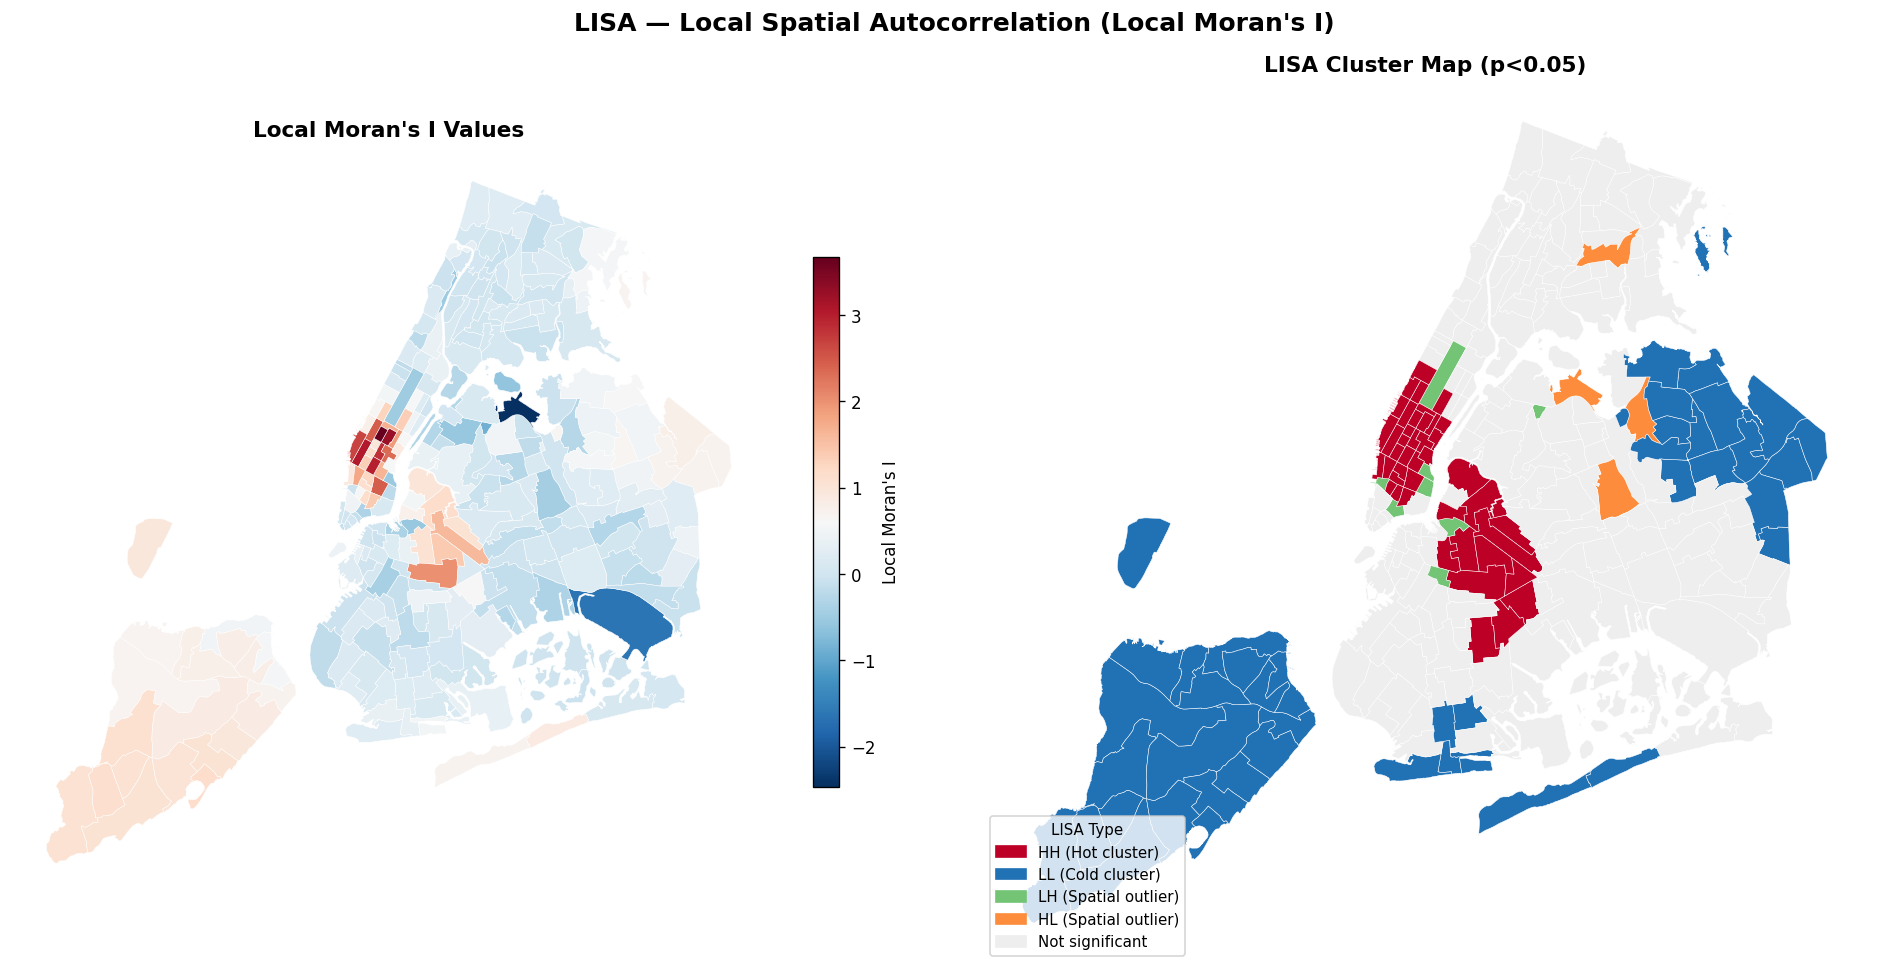

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Left: LISA I values ──────────────────────────────────────
ax = axes[0]
gdf_gi.plot(column='lisa_I', ax=ax, cmap='RdBu_r',
            legend=True,
            legend_kwds={'label': "Local Moran's I", 'shrink': 0.6},
            edgecolor='white', linewidth=0.3)
ax.set_title("Local Moran's I Values", fontsize=13, fontweight='bold')
ax.set_axis_off()

# ── Right: LISA cluster map ──────────────────────────────────
ax = axes[1]
LISA_COLOR_MAP = {
    'HH (Hot cluster)':      '#BD0026',
    'LL (Cold cluster)':     '#2171B5',
    'LH (Spatial outlier)':  '#74C476',
    'HL (Spatial outlier)':  '#FD8D3C',
    'Not significant':       '#EEEEEE',
}
gdf_gi['lisa_color'] = gdf_gi['lisa_class'].map(LISA_COLOR_MAP).fillna('#EEEEEE')
gdf_gi.plot(ax=ax, color=gdf_gi['lisa_color'], edgecolor='white', linewidth=0.3)
ax.set_title('LISA Cluster Map (p<0.05)', fontsize=13, fontweight='bold')
ax.set_axis_off()

legend_patches = [
    mpatches.Patch(color=c, label=l)
    for l, c in LISA_COLOR_MAP.items()
    if l in gdf_gi['lisa_class'].unique()
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9,
          title='LISA Type', title_fontsize=9)

plt.suptitle("LISA — Local Spatial Autocorrelation (Local Moran's I)",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/spatial/07_lisa_cluster.png', bbox_inches='tight', dpi=150)
plt.show()

## 6 · Save Results to PostgreSQL

In [18]:
# Create spatial_statistics table if not exists
create_sql = """
CREATE TABLE IF NOT EXISTS spatial_statistics (
    id                       BIGSERIAL,
    analysis_time            TIMESTAMPTZ NOT NULL DEFAULT NOW(),
    zone_id                  INTEGER REFERENCES taxi_zones(zone_id),
    gi_star_z                FLOAT,
    gi_star_p                FLOAT,
    moran_i                  FLOAT,
    lisa_cluster             VARCHAR(20),
    is_significant_hotspot   BOOLEAN,
    PRIMARY KEY (id, analysis_time)
);
SELECT create_hypertable('spatial_statistics', 'analysis_time',
                         chunk_time_interval => INTERVAL '1 day',
                         if_not_exists => TRUE);
CREATE INDEX IF NOT EXISTS idx_spatial_stats_zone
    ON spatial_statistics (zone_id, analysis_time DESC);
"""
with engine.connect() as conn:
    for stmt in create_sql.strip().split(';'):
        if stmt.strip():
            conn.execute(text(stmt))
    conn.commit()
print('spatial_statistics hypertable ready.')

spatial_statistics hypertable ready.


In [19]:
# Write results
from datetime import datetime, timezone

run_time = datetime.now(timezone.utc)

out_df = pd.DataFrame({
    'analysis_time':          run_time,
    'zone_id':                gdf_gi['zone_id'].astype(int),
    'gi_star_z':              gdf_gi['gi_z'],
    'gi_star_p':              gdf_gi['gi_p'],
    'moran_i':                gdf_gi['lisa_I'],
    'lisa_cluster':           gdf_gi['lisa_class'],
    'is_significant_hotspot': (gdf_gi['gi_p'] < 0.05) & (gdf_gi['gi_z'] > 1.96),
})

out_df.to_sql('spatial_statistics', engine, if_exists='append', index=False)
print(f'Written {len(out_df)} rows with analysis_time={run_time.isoformat()}')

Written 261 rows with analysis_time=2026-06-22T06:35:52.081412+00:00


## 7 · Summary Findings

In [20]:
print('=' * 60)
print('SPATIAL ANALYSIS SUMMARY FINDINGS')
print('=' * 60)

hot99  = (gdf_gi['hotspot_class'] == 'Hot spot 99%').sum()
hot95  = (gdf_gi['hotspot_class'] == 'Hot spot 95%').sum()
cold99 = (gdf_gi['hotspot_class'] == 'Cold spot 99%').sum()
hh     = (gdf_gi['lisa_class'] == 'HH (Hot cluster)').sum()
ll     = (gdf_gi['lisa_class'] == 'LL (Cold cluster)').sum()

print(f"""
1. GLOBAL AUTOCORRELATION:
   Moran's I = {moran_global.I:.4f}, p = {moran_global.p_sim:.4f}
   → {'Significant positive' if moran_global.p_sim < 0.05 and moran_global.I > 0 else 'Not significant'} spatial clustering

2. GETIS-ORD Gi* HOTSPOTS:
   Hot spot 99% confidence: {hot99} zones
   Hot spot 95% confidence: {hot95} zones
   Cold spot 99% confidence: {cold99} zones

3. LISA CLUSTERS:
   HH clusters (high-high): {hh} zones
   LL clusters (low-low):   {ll} zones

4. OUTPUT FILES:
   outputs/spatial/01_choropleth_demand.png
   outputs/spatial/02_choropleth_interactive.html
   outputs/spatial/03_kde_density.png
   outputs/spatial/04_kde_heatmap_interactive.html
   outputs/spatial/05_getis_ord_hotspot.png
   outputs/spatial/06_moran_global.png
   outputs/spatial/07_lisa_cluster.png
""")

SPATIAL ANALYSIS SUMMARY FINDINGS

1. GLOBAL AUTOCORRELATION:
   Moran's I = 0.3546, p = 0.0010
   → Significant positive spatial clustering

2. GETIS-ORD Gi* HOTSPOTS:
   Hot spot 99% confidence: 34 zones
   Hot spot 95% confidence: 16 zones
   Cold spot 99% confidence: 30 zones

3. LISA CLUSTERS:
   HH clusters (high-high): 43 zones
   LL clusters (low-low):   45 zones

4. OUTPUT FILES:
   outputs/spatial/01_choropleth_demand.png
   outputs/spatial/02_choropleth_interactive.html
   outputs/spatial/03_kde_density.png
   outputs/spatial/04_kde_heatmap_interactive.html
   outputs/spatial/05_getis_ord_hotspot.png
   outputs/spatial/06_moran_global.png
   outputs/spatial/07_lisa_cluster.png



In [21]:
import os, shutil
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive', force_remount=False)

DRIVE_OUTPUTS = '/content/drive/MyDrive/Colab Notebooks/ride_hailing_outputs'
os.makedirs(DRIVE_OUTPUTS, exist_ok=True)

n = 0
for root, _, files_ in os.walk('outputs'):
    for f in files_:
        src = os.path.join(root, f)
        rel = os.path.relpath(src, 'outputs')
        dst = os.path.join(DRIVE_OUTPUTS, rel)
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy2(src, dst)
        n += 1

print(f'Synced {n} files to {DRIVE_OUTPUTS}')

Synced 7 files to /content/drive/MyDrive/Colab Notebooks/ride_hailing_outputs
